## CMPE-257, Machine Learning, Summer 2025
## Week 6: Polynomial Regressions
In this workbook, you will be exploring non-linear relations among variabes

- polynomial regressions
- splines and KNN regressions
- generalized additive models (GAMs)

In [1]:
# Quoc Dung Lam

In [2]:
# loads required modules
import pickle
import numpy as np
import random as rd #?????
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import legendre
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

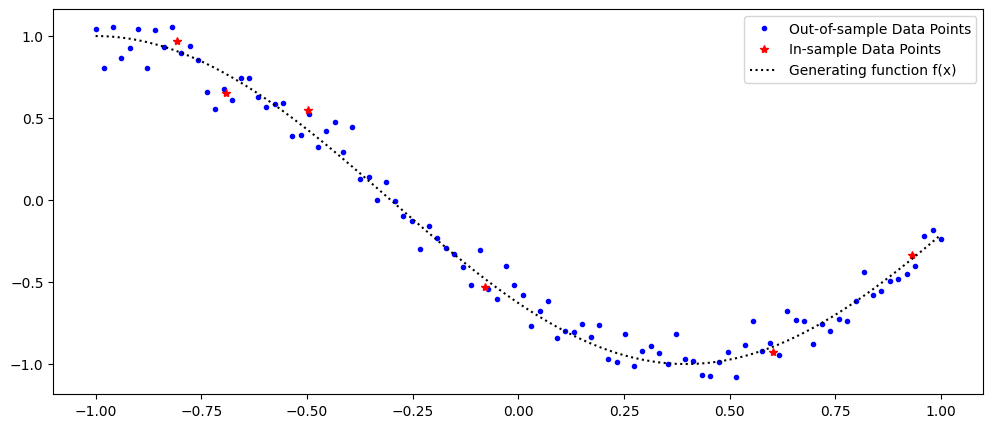

In [3]:
# Loads and plots the dataset "w6_data.pkl" to be used in Parts 1 and 2
# The dataset is given in two dataframes data[0] and data[1] corresponding to the in-sample set (6 data samples)
# and out-of-sample set (100 data samples), respectively. Each dataframe contains 3 columns: the input variable (x),  
# the noisless target function (f), and the noisy target/observations (y)

with open("w6_data.pkl", "rb") as file:
    data = pickle.load(file)

fig, ax = plt.subplots(1,1,figsize=(12,5))
ax.plot(data[1]['x'].values,data[1]['y'].values,'.b',label='Out-of-sample Data Points')
ax.plot(data[0]['x'].values,data[0]['y'].values,'*r',label='In-sample Data Points')
ax.plot(data[1]['x'].values,data[1]['f'].values,':k',label='Generating function f(x)')
ax.legend()#ncol=2)
plt.show()

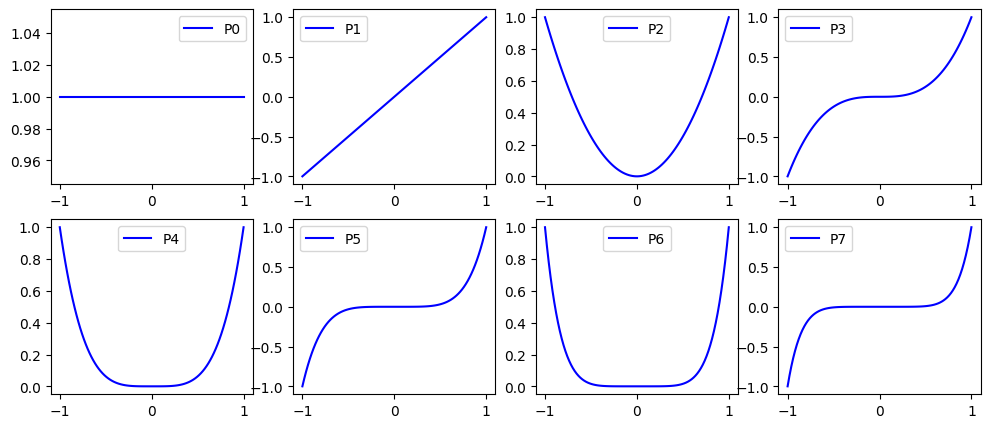

In [4]:
# Generates new predictors by adding single polynomial transformations Pk(x) = x^k of the input variable x
# for the first eight values of k = 0, 1, 2, ... 7; and plots the generated predictors (plots only out-of-sample)

npols = 8
ptags = ['P'+str(k) for k in range(npols)]

for n in range(2):
    for k in range(npols):
        data[n][ptags[k]] = data[n]['x']**k

fig, axs = plt.subplot_mosaic([[0,1,2,3],[4,5,6,7]],figsize=(12,5))
for k, ax in axs.items():
    ax.plot(data[1]['x'].values,data[1][ptags[k]].values, '-b',label = ptags[k])
    ax.legend()
plt.show()

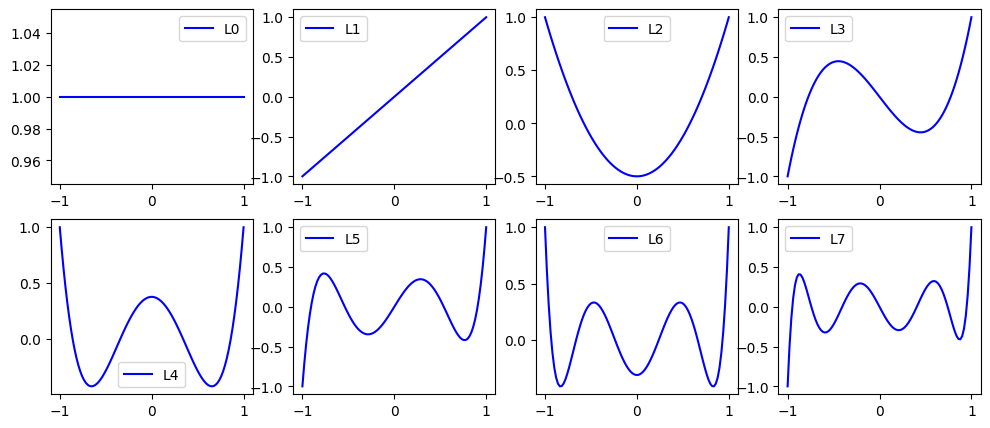

In [5]:
# Generates new predictors by adding Legender polynomial transformations Lk(x) = legendre(k,x) of the input variable x
# for the first eight values of k = 0, 1, 2, ... 7; and plots the generated predictors (plots only out-of-sample)

npols = 8
ltags = ['L'+str(k) for k in range(npols)]
PL = {k:legendre(k) for k in range(npols)}

for n in range(2):
    for k in range(npols):
        data[n][ltags[k]] = PL[k](data[n]['x'].values)

fig, axs = plt.subplot_mosaic([[0,1,2,3],[4,5,6,7]],figsize=(12,5))
for k, ax in axs.items():
    ax.plot(data[1]['x'].values,data[1][ltags[k]].values, '-b',label = ltags[k])
    ax.legend()
plt.show()

In [6]:
# Verifies the orthogonality of legendre polynomials (and non-orthogonality of single polynomials)
# by approximating the integrals of Li(x)Lj(x) and the integrals of Pi(x)Pj(x) for ij = 00, 01, 02, ... 77

xvals = np.linspace(-1,1,10000)
dx = (xvals[-1]-xvals[0])/(len(xvals)-1)

pmtx = np.array([xvals**k for k in range(npols)])
pintgl = pd.DataFrame(np.matmul(dx*pmtx,pmtx.T)).map('{:4.2f}'.format)
plabel = 'Product integrals for simple polynomials'

lmtx = np.array([PL[k](xvals) for k in range(npols)])
lintgl = pd.DataFrame(np.matmul(dx*lmtx,lmtx.T)).map('{:4.2f}'.format)
llabel = 'Product integrals for Legendre polynomials'

separator = pd.DataFrame(data=[' ']*npols,columns=[' '])
pd.concat([lintgl,separator,pintgl],axis=1,keys=[llabel,'',plabel])

Product integrals for Legendre polynomials                             \
                                           0      1      2     3      4   
0                                       2.00   0.00   0.00  0.00   0.00   
1                                       0.00   0.67  -0.00  0.00  -0.00   
2                                       0.00   0.00   0.40  0.00   0.00   
3                                       0.00   0.00   0.00  0.29   0.00   
4                                       0.00  -0.00   0.00  0.00   0.22   
5                                      -0.00   0.00   0.00  0.00   0.00   
6                                       0.00  -0.00   0.00  0.00   0.00   
7                                       0.00   0.00   0.00  0.00   0.00   

                         Product integrals for simple polynomials         \
       5      6     7                                           0      1   
0  -0.00   0.00  0.00                                        2.00   0.00   
1   0.00  -0.00  0.00                                        0.00   0.67   
2   0.00   0.00  0.00                                        0.67   0.00   
3   0.00   0.00  0.00                                        0.00   0.40   
4   0.00   0.00  0.00                                        0.40  -0.00   
5   0.18   0.00  0.00                                       -0.00   0.29   
6   0.00   0.15  0.00                                        0.29   0.00   
7   0.00   0.00  0.13                                       -0.00   0.22   

                                             
       2      3      4      5      6      7  
0   0.67   0.00   0.40  -0.00   0.29  -0.00  
1   0.00   0.40  -0.00   0.29  -0.00   0.22  
2   0.40  -0.00   0.29  -0.00   0.22   0.00  
3  -0.00   0.29  -0.00   0.22   0.00   0.18  
4   0.29   0.00   0.22   0.00   0.18   0.00  
5   0.00   0.22   0.00   0.18   0.00   0.15  
6   0.22   0.00   0.18   0.00   0.15   0.00  
7   0.00   0.18   0.00   0.15   0.00   0.13

# PART 1: Polynomial Regressions

In [7]:
# Consider the same function used in W4S1.ipynb to conduct linear regressions by using either the 
# LinearRegression, Ridge, or Lasso classes in scikit learn. It admits the following input parmeters:
# datasets: a two element array of dataframes containing the in-sample and out-of-sample data sets
# variables: a list with the column names (from dataset dataframes) to be used as preditors in the regression
# regtype: the regression algorithm to be used (i.e. 'linear', 'ridge' or 'lasso')
# alpha (lambda): the shrinkage factor (only used in 'ridge' and 'lasso'), if zero then 'linear' is used
# verbose: a boolean flag to display the obtained coefficients, regression errors and R2 score
# plot: a boolean flag to plot the data and the resulting model curve (out-of-sample predictions)

def do_regression(datasets,variables,regtype='linear',alpha=0.0,verbose=False,plot=False):
    result = {}
    in_X = datasets[0][variables].to_numpy()
    in_Y = datasets[0]['y'].to_numpy()
    if alpha==0.0 or regtype=='linear':
        reg = LinearRegression(fit_intercept=False).fit(in_X,in_Y)
    elif regtype=='ridge':
        reg = Ridge(alpha=alpha,fit_intercept=False).fit(in_X,in_Y)
    elif regtype=='lasso':
        reg = Lasso(alpha=alpha,fit_intercept=False).fit(in_X,in_Y)
        
    in_pred = reg.predict(in_X)
    in_err = mean_squared_error(in_Y, in_pred)
    out_X = datasets[1][variables].to_numpy()
    out_Y = datasets[1]['y'].to_numpy()
    out_pred = reg.predict(out_X)
    out_err = mean_squared_error(out_Y, out_pred)
    out_r2 = reg.score(out_X,out_Y)
    
    result['model']=reg
    result['coefficients']=reg.coef_
    result['intercept']=reg.intercept_
    result['in_error']=in_err
    result['out_error']=out_err
    result['out_r2']=out_r2
    result['curve']=out_pred

    if verbose:
        print('Coefficients: '.rjust(21),end='')
        print(', '.join(['{:8.6f}'.format(x) for x in reg.coef_]))
        print('Intercept: '.rjust(21),end='')
        print(reg.intercept_)
        print('In-sample Error: '.rjust(21)+str(in_err))
        print('Out-of-sample Error: '.rjust(21)+str(out_err))
        print('Out-of-sample R2: '.rjust(21)+str(out_r2))

    if plot:
        fig, ax = plt.subplots(1,1,figsize=(10,4))
        ax.plot(datasets[1]['x'].values,datasets[1]['f'].values,':k',label='generating function f(x)')
        ax.plot(datasets[1]['x'].values,out_pred,'-b',label='estimated function g(x)')
        ax.plot(datasets[0]['x'].values,in_Y,'*k',label='in-sample data points')
        ax.plot(datasets[1]['x'].values,out_Y,'.y',label='out-of-sample data points')
        ax.legend(ncol=2)

    return result

In [8]:
display(data)

[          x         f         y   P0        P1        P2        P3        P4  \
 0 -0.808660  0.908750  0.967281  1.0 -0.808660  0.653930 -0.528807  0.427625   
 1 -0.496913  0.424900  0.550292  1.0 -0.496913  0.246923 -0.122699  0.060971   
 2  0.601725 -0.895034 -0.925152  1.0  0.601725  0.362073  0.217869  0.131097   
 3 -0.078093 -0.482490 -0.527395  1.0 -0.078093  0.006098 -0.000476  0.000037   
 4 -0.690735  0.767512  0.653754  1.0 -0.690735  0.477115 -0.329560  0.227639   
 5  0.931373 -0.358630 -0.335178  1.0  0.931373  0.867455  0.807924  0.752479   
 
          P5            P6            P7   L0        L1        L2        L3  \
 0 -0.345803  2.796367e-01 -2.261309e-01  1.0 -0.808660  0.480895 -0.109028   
 1 -0.030297  1.505510e-02 -7.481078e-03  1.0 -0.496913 -0.129616  0.438622   
 2  0.078884  4.746669e-02  2.856190e-02  1.0  0.601725  0.043110 -0.357916   
 3 -0.000003  2.268110e-07 -1.771229e-08  1.0 -0.078093 -0.490852  0.115948   
 4 -0.157238  1.086101e-01 -7.502081

In [9]:
print(f'{ptags}')

['P0', 'P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7']


Regression using k = 0
       Coefficients: 0.063934
          Intercept: 0.0
    In-sample Error: 0.4812863434344779
Out-of-sample Error: 0.5337233305481665
   Out-of-sample R2: -0.1563209806533732
Regression using k = 1
       Coefficients: -0.016981, -0.896882
          Intercept: 0.0
    In-sample Error: 0.13743823397999153
Out-of-sample Error: 0.17200372761041455
   Out-of-sample R2: 0.6273508996089108
Regression using k = 2
       Coefficients: -0.570658, -1.032599, 1.242962
          Intercept: 0.0
    In-sample Error: 0.02651293767713804
Out-of-sample Error: 0.04654912212931838
   Out-of-sample R2: 0.8991505083844756
Regression using k = 3
       Coefficients: -0.581811, -1.712864, 1.108861, 1.111252
          Intercept: 0.0
    In-sample Error: 0.007172541082941384
Out-of-sample Error: 0.011087687162465507
   Out-of-sample R2: 0.9759783307960099
Regression using k = 4
       Coefficients: -0.644618, -1.789800, 1.622548, 1.299251, -0.634869
          Intercept: 0.0
    In-sampl

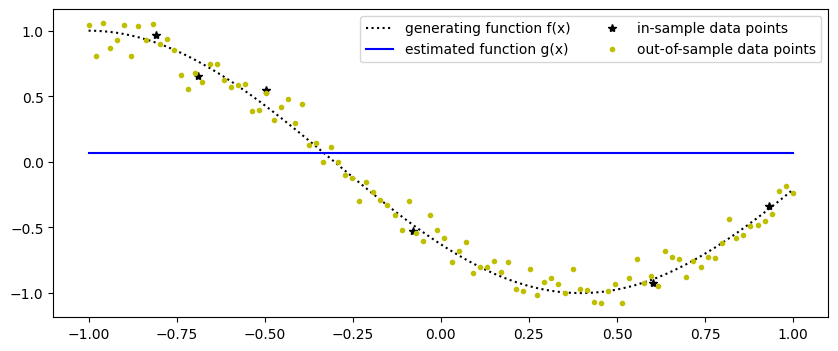

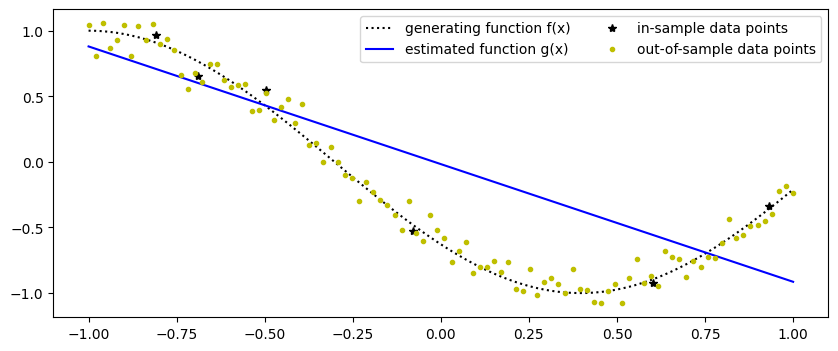

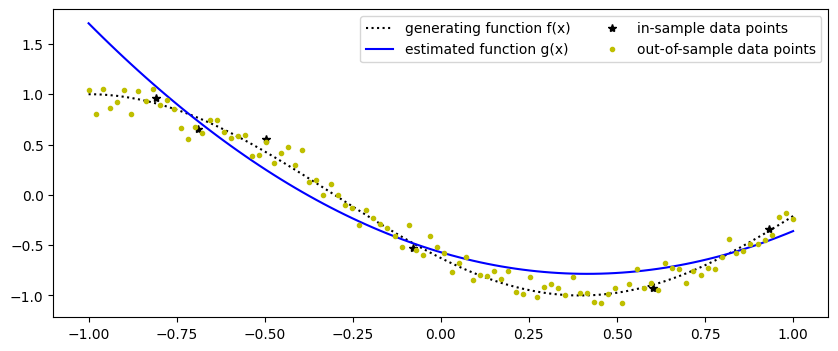

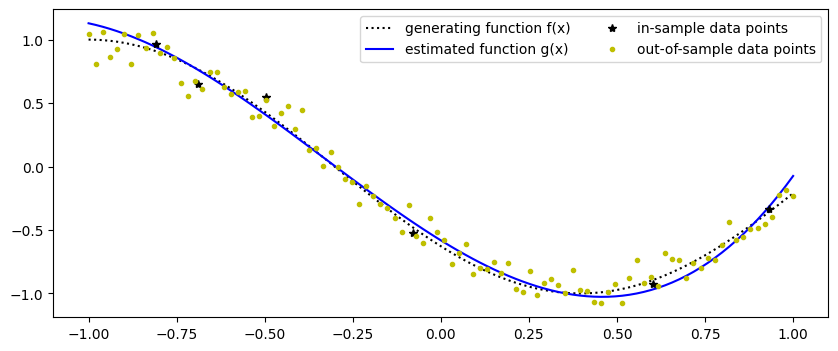

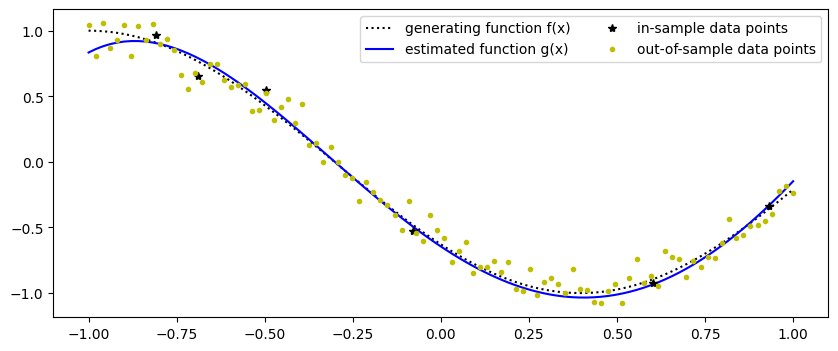

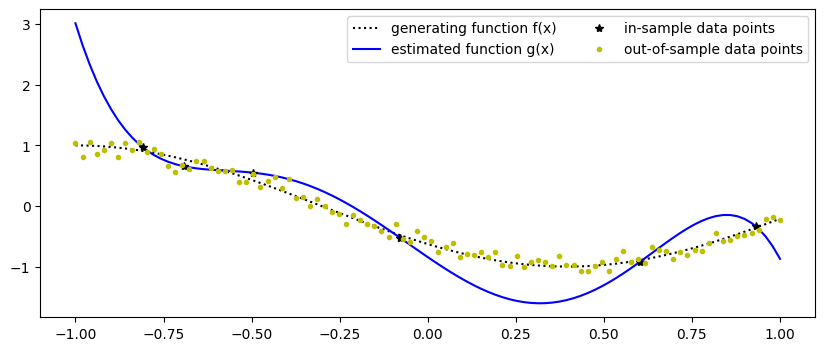

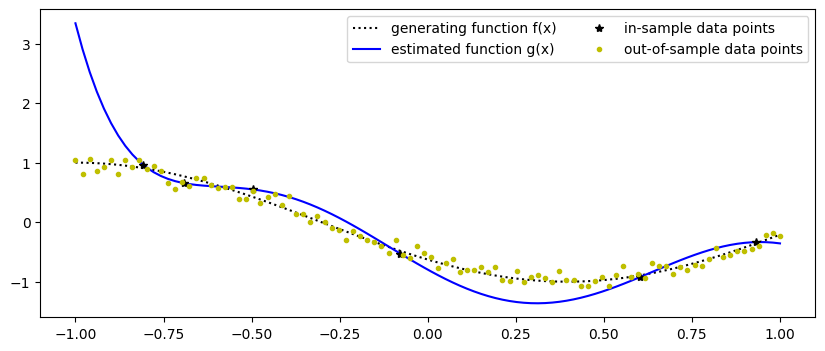

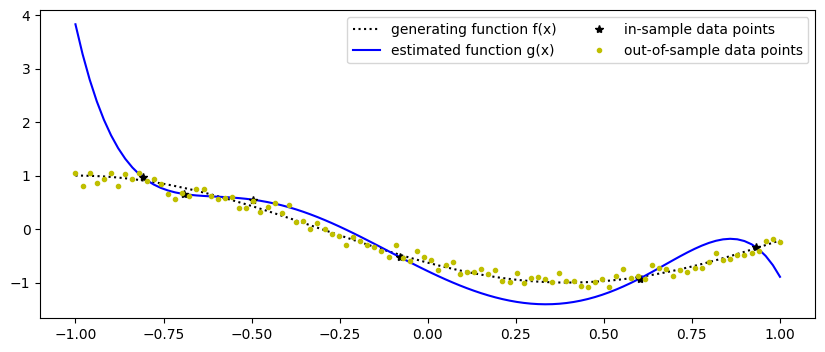

In [10]:
# Exercise #1: perform eight linear regressions with predictors of increasing polynomial complexity
# {P0(x)}, {P0(x),P1(x)}, {P0(x),P1(x),P2(x)}, ... {P0(x),P1(x), ... P7(x)} and generate plots for the
# in-sample MSE and the out-of-sample MSE versus overall polynomial degree (collect also the resulting
# out-of-sample predictions g(xout) as you will need to plot them in the second part of this exercise)

predictor_list = []
ex1_results = []
for k in range(len(ptags)):
    predictor_list.append(ptags[k])
    print(f"Regression using k = {k}")
    temp_model = do_regression(data, predictor_list, verbose=True, plot=True)
    ex1_results.append(temp_model)


In [11]:
# Based in your results from exercise #1, what is the best model? Where and why do you think overfitting occurs? 
# The best model is when k = 4 (P0,P1,P2,P3) with In-sample Error: 0.005830912608828104
# Out-of-sample Error: 0.009875418205098995
# Out-of-sample R2: 0.9786047328087493
# Overfitting occurs when we use too little predictors (1,2) or too many predictors (5,6,7). Because the features we're using 
# are providing little prediction accuracy.

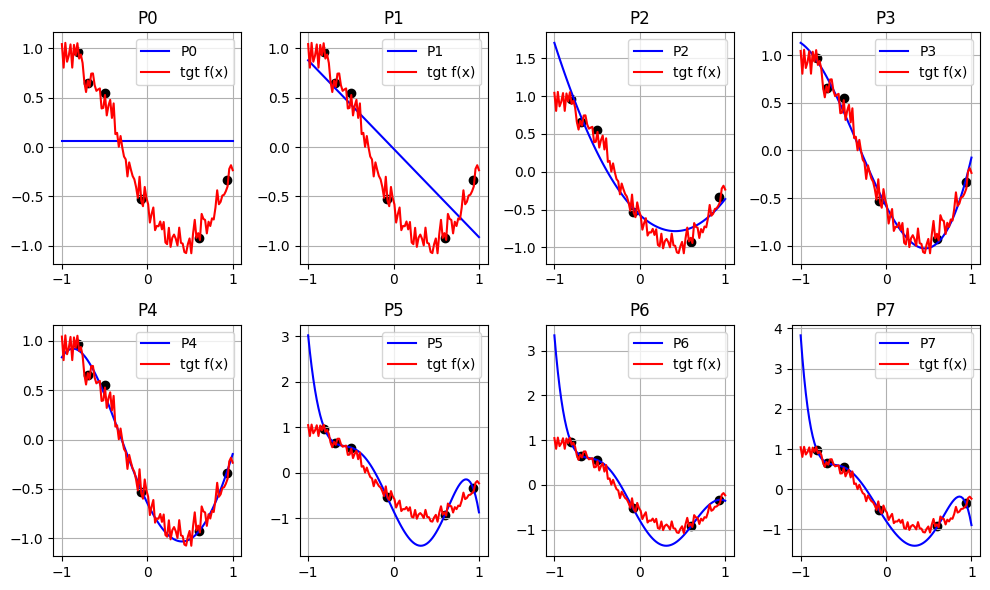

In [12]:
# Exercise #1 (continuation): plot the resulting out-of-sample predictions g(xout) for all eight models
# computed (generate one subplot per model) along with the target function f(x) and the in-sample data points 

fig, ax = plt.subplots(2,4,figsize=(10,6))

for k in range(len(ptags)):
    row = k // 4
    col = k % 4
    ax[row, col].plot(data[1]['x'].values, ex1_results[k]['curve'], '-b', label=ptags[k])
    ax[row, col].plot(data[1]['x'].values, data[1]['y'], '-r', label='tgt f(x)')
    ax[row, col].scatter(data[0]['x'].values, data[0]['y'], color='black')
    ax[row, col].set_title(ptags[k])
    ax[row, col].legend()
    ax[row, col].grid(True)

plt.tight_layout()
plt.show()

In [13]:
# What are your main conclusions from exercise #1?
# Too little prediction features cause under fitting, too many features cause overfitting.
# Choosing the optimal number of feature using is the main factor of generating a good model.

ptags = ['P0', 'P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7']
ltags = ['L0', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6', 'L7']
Regression using L = 0
       Coefficients: 0.063934
          Intercept: 0.0
    In-sample Error: 0.4812863434344779
Out-of-sample Error: 0.5337233305481665
   Out-of-sample R2: -0.1563209806533732
Regression using L = 1
       Coefficients: -0.016981, -0.896882
          Intercept: 0.0
    In-sample Error: 0.13743823397999153
Out-of-sample Error: 0.17200372761041455
   Out-of-sample R2: 0.6273508996089108
Regression using L = 2
       Coefficients: -0.156337, -1.032599, 0.828642
          Intercept: 0.0
    In-sample Error: 0.026512937677138044
Out-of-sample Error: 0.046549122129318304
   Out-of-sample R2: 0.8991505083844757
Regression using L = 3
       Coefficients: -0.212190, -1.046113, 0.739241, 0.444501
          Intercept: 0.0
    In-sample Error: 0.007172541082941385
Out-of-sample Error: 0.011087687162465477
   Out-of-sample R2: 0.9759783307960099
Regression using 

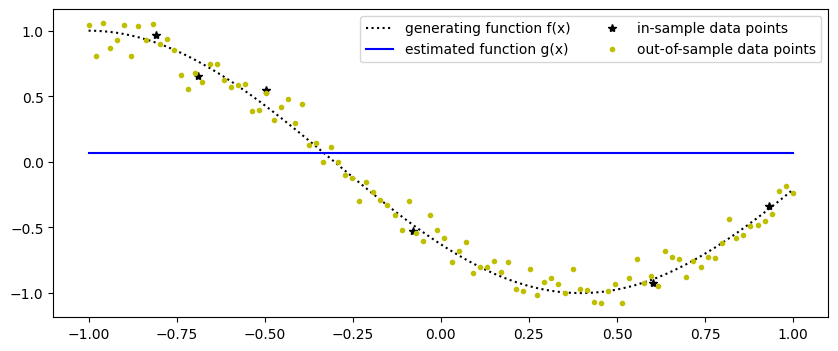

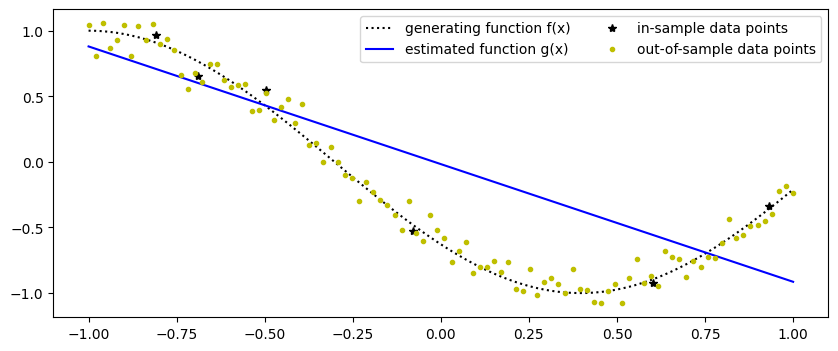

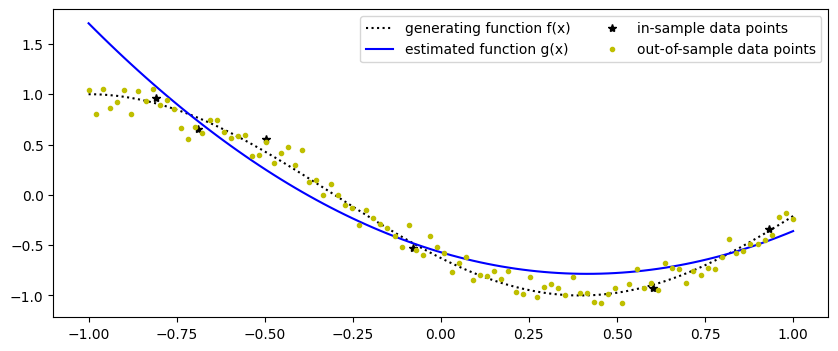

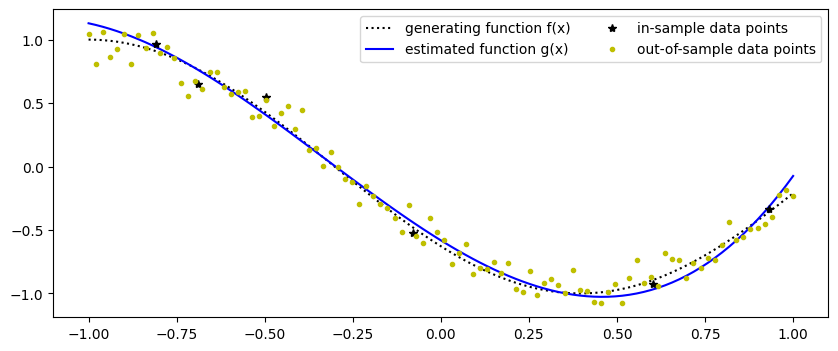

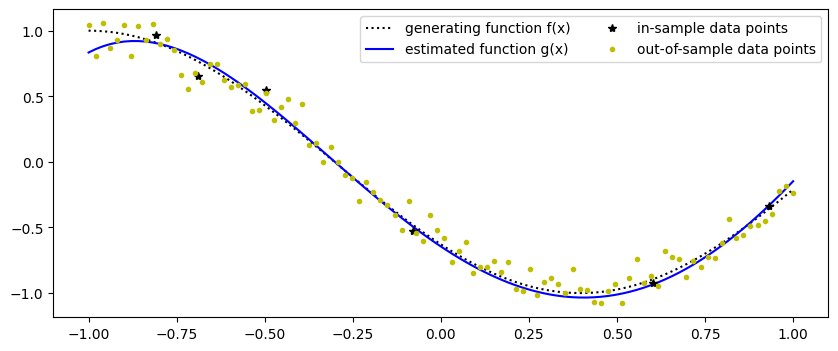

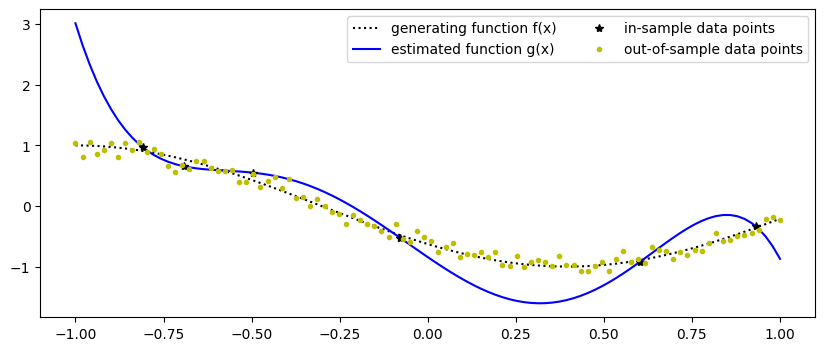

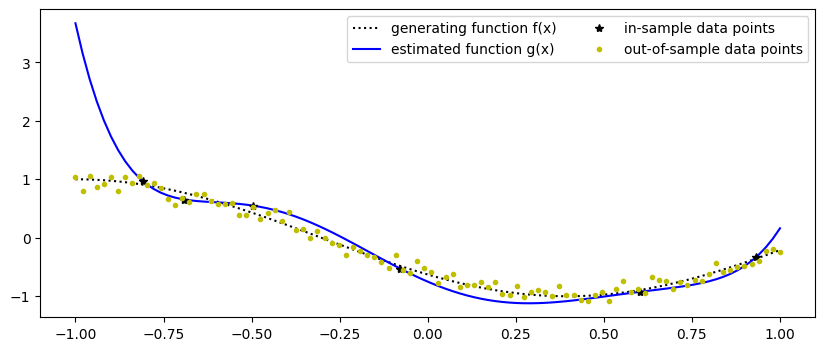

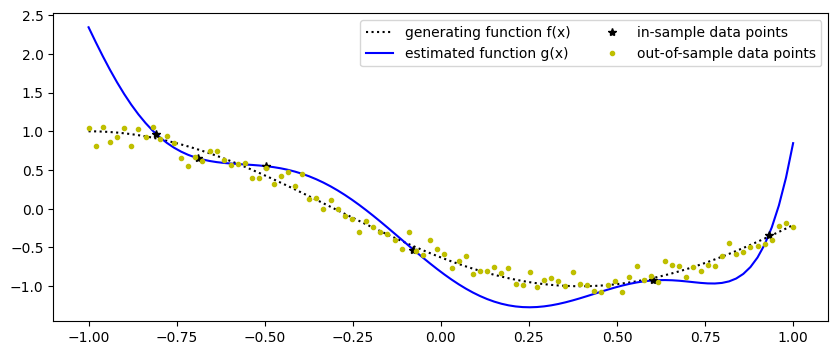

In [14]:
# Exercise #2: perform eight linear regressions with predictors of increasing polynomial complexity
# {L0(x)}, {L0(x),L1(x)}, {L0(x),L1(x),L2(x)}, ... {L0(x),L1(x), ... L7(x)} and generate plots for the
# in-sample MSE and the out-of-sample MSE versus overall polynomial degree (collect also the resulting
# out-of-sample predictions g(xout) as you will need to plot them in the second part of this exercise)

lpredictor_list = []
ex2_results = []

print(f"ptags = {ptags}")
print(f"ltags = {ltags}")

#predictor_list = []
for k in range(len(ltags)):
    #print("  ptags[k] column sample:", data[0][ptags[k]].head().tolist())
    #print("  ltags[k] column sample:", data[0][ltags[k]].head().tolist())
    lpredictor_list.append(ltags[k])
    print(f"Regression using L = {k}")
    temp_model = do_regression(data, lpredictor_list, verbose=True, plot=True)
    ex2_results.append(temp_model)
    # print(f"Regression using P = {k}")
    # predictor_list.append(ptags[k])
    # temp_model = do_regression(data, predictor_list, verbose=True, plot=True)


In [15]:
# Based in your results from exercise #2, what is the best model? Where and why do you think overfitting occurs?
# How your results from exercise #2 compare to those from exercise #1?
# Based on the result, the best model is still when k=4. Overfitting occurs when we using more features.
# Although it's almost identical for k = 0 -> k = 5, it has a clear different at k=7 where L'R2 is 0.7 and
# P'R2 is 0.3. The Legender polynomial produces a better result for this dataset

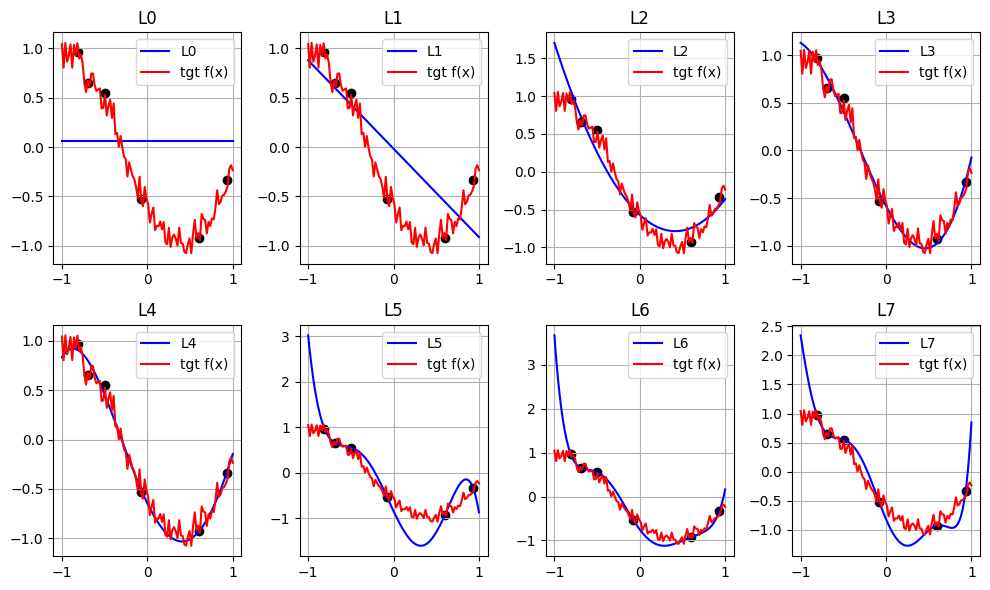

In [16]:
# Exercise #2 (continuation): plot the resulting out-of-sample predictions g(xout) for all eight models
# computed (generate one subplot per model) along with the target function f(x) and the in-sample data points 

fig, ax = plt.subplots(2,4,figsize=(10,6))

for k in range(len(ltags)):
    row = k // 4
    col = k % 4
    ax[row, col].plot(data[1]['x'].values, ex2_results[k]['curve'], '-b', label=ltags[k])
    ax[row, col].plot(data[1]['x'].values, data[1]['y'], '-r', label='tgt f(x)')
    ax[row, col].scatter(data[0]['x'].values, data[0]['y'], color='black')
    ax[row, col].set_title(ltags[k])
    ax[row, col].legend()
    ax[row, col].grid(True)

plt.tight_layout()
plt.show()


In [17]:
# What are your main conclusions from exercise #2? How these compare from those from exercise #1?
# The best Model is when k=4. Overfitting occurs when using more complexity polynominal
# It produces the same result from exercise #1 overall, but Legendre polynominal will shine with large feature scales.

# PART 2: Splines and KNN Regressions

In [18]:
# loads additional modules required in PART 2
from tqdm import tqdm
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import SplineTransformer
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

In [19]:
# Gets the "california_housing_dataset" and displays its description

housing = fetch_california_housing()
print(housing['DESCR'])

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

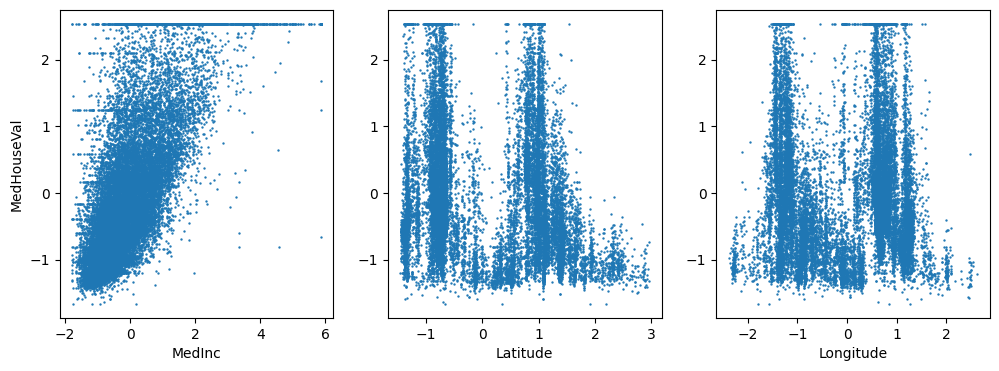

In [20]:
# Selects a subset of input variables (MedInc, Latitude, Longitude), along with the target variable,
# normalizes the dataset (by using mean-var normalization) and generates cross-plots for each of the 
# three input variables vs the target variable  

selected_features = [0,6,7]
features = housing.data[:,selected_features]
feature_labels = [housing.feature_names[x] for x in selected_features]
target = housing.target.reshape(-1, 1)
target_label = housing.target_names

normdata = pd.DataFrame(data = np.concatenate([features,target],axis=1), columns = feature_labels+target_label)
normdata = (normdata-normdata.mean())/normdata.std()

fig, axs = plt.subplots(1,3,figsize=(12,4))
for k, ax in enumerate(axs):
    ax.scatter(normdata[feature_labels[k]],normdata[target_label[0]],marker='.',s=2.0)
    ax.set_xlabel(feature_labels[k])
    if k == 0: ax.set_ylabel(target_label[0])
plt.show()

In [21]:
# Conducts cubic spline regressions between the input variable 'Latitude' and the target 'MedHouseVal'
# Uses a validation approach to determine the optimal number of knots. A total number of 1000 validations
# with random splits of 50% train and 50% test are conducted. Notice the scikit-learn pipeline constructor 
# is used to chain the splinetransformer with the ridge regressor (a shrinkage factor of 0.01 is used). 

scores = [] # will collect mean value and std for both train and test MSE over the knot sweep 
knots = [x for x in range(17,26)]
trn_data = normdata['Latitude'].values.reshape(-1, 1)
trn_trgt = normdata['MedHouseVal'].values.reshape(-1, 1)

for k in knots:
    tr_mse = []
    ts_mse = []
    for sim in tqdm(range(1000),desc=str(k)+' knots:'):

        trn_x, tst_x, trn_y, tst_y = train_test_split(trn_data, trn_trgt, test_size=0.5)
        
        sfeatures = SplineTransformer(n_knots=k, degree=3, extrapolation='linear')
        sregression = Ridge(alpha=0.01)
        smodel = make_pipeline(sfeatures,sregression).fit(trn_x,trn_y)
        
        tr_mse.append(mean_squared_error(trn_y,smodel.predict(trn_x)))
        ts_mse.append(mean_squared_error(tst_y,smodel.predict(tst_x)))
        
    scores.append({'knots':k,'tr_avg':np.mean(tr_mse),'tr_std':np.std(tr_mse),'ts_avg':np.mean(ts_mse),'ts_std':np.std(ts_mse)})
scores = pd.DataFrame(scores)

17 knots::   0%|          | 0/1000 [00:00<?, ?it/s]

25 knots:: 100%|██████████| 1000/1000 [00:13<00:00, 73.97it/s]


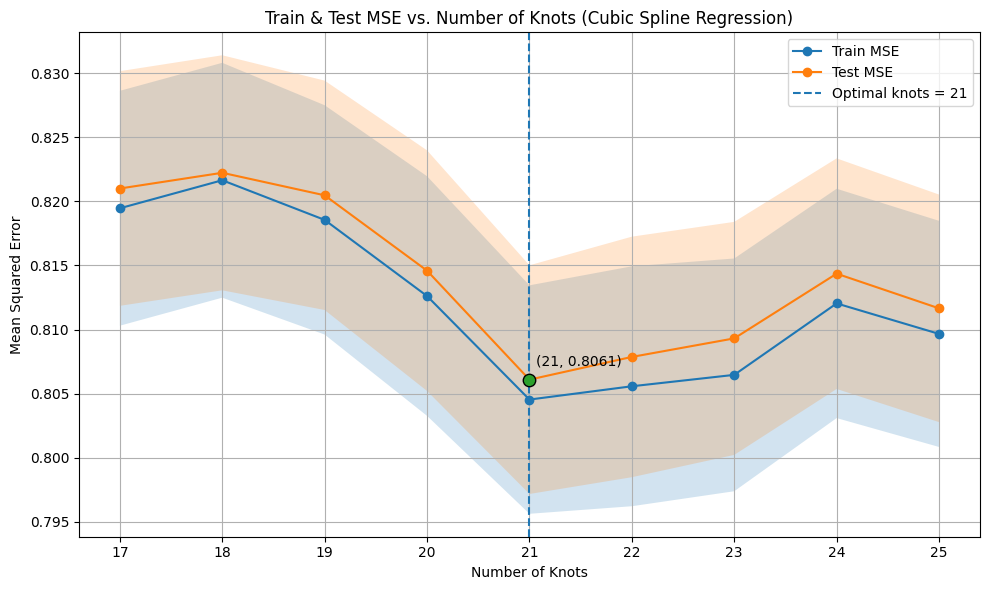

In [22]:
# Exercise 3: plot mean values, along with mean ± std, for both the train MSE and test MSE computed
# in the previous simulations vs the number of knots used in each simulation. Display in the plot the
# corresponding optimal number of knots that produced the smallest test MSE. (Note: all values required 
# for the plots are contained in the scores dataframe)

optknots = scores.sort_values(by='ts_avg')['knots'].values[0]

# Get the optimal test MSE value for annotation
opt_ts_mse = scores.loc[scores['knots'] == optknots, 'ts_avg'].iloc[0]

x = scores['knots'].values

plt.figure(figsize=(10, 6))

# Train: mean line + ± std band
plt.plot(x, scores['tr_avg'], marker='o', label='Train MSE')
plt.fill_between(x, scores['tr_avg'] - scores['tr_std'], scores['tr_avg'] + scores['tr_std'], alpha=0.2)

# Test: mean line + ± std band
plt.plot(x, scores['ts_avg'], marker='o', label='Test MSE')
plt.fill_between(x, scores['ts_avg'] - scores['ts_std'], scores['ts_avg'] + scores['ts_std'], alpha=0.2)

# Mark optimal knots (smallest test MSE)
plt.axvline(optknots, linestyle='--', label=f'Optimal knots = {int(optknots)}')
plt.scatter([optknots], [opt_ts_mse], s=80, edgecolor='k', zorder=5)

# Annotate the optimal point
plt.annotate(f'({int(optknots)}, {opt_ts_mse:.4f})',
             xy=(optknots, opt_ts_mse),
             xytext=(5, 10),
             textcoords='offset points')

plt.xlabel('Number of Knots')
plt.ylabel('Mean Squared Error')
plt.title('Train & Test MSE vs. Number of Knots (Cubic Spline Regression)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# What are you main observations from the plot generated in exercise #3?
# The MSE are not optimal when the number of knots is less than the optimal knot. The MSE are getting higher when the number of knots increase.
# Choosing the right number knots become the key of a good model.

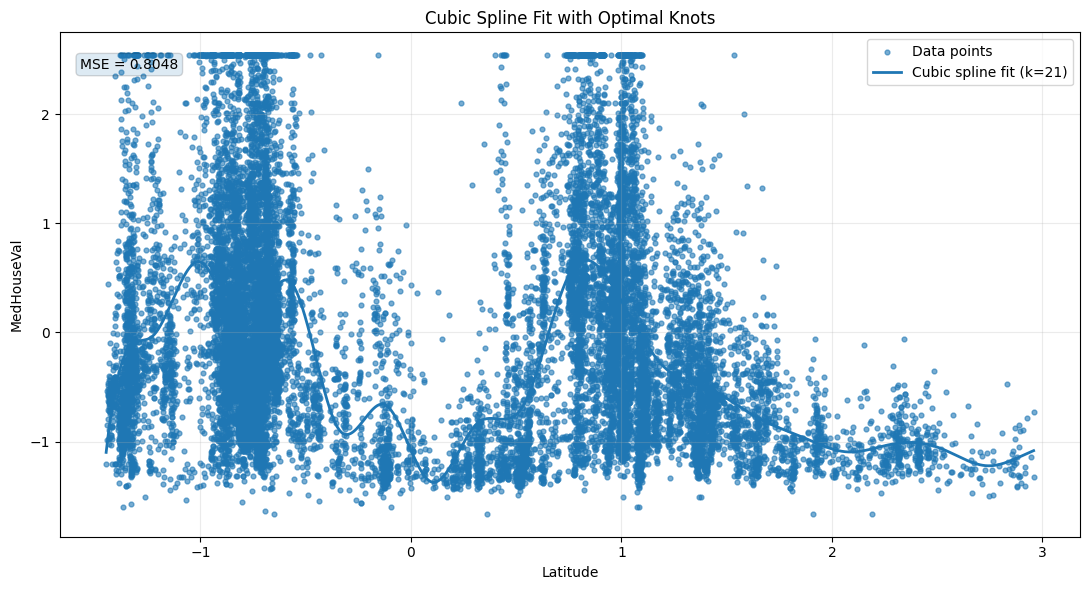

In [ ]:
# Exercise 4: use the optimal number of knots identified in exercise #3 and all available
# data points to train a new cubic spline model. Generte a plot displaying all the data
# points, the learned cubic spline predictions, and the location of the knots. Also, display
# somewhere in the plot the MSE between the data and the predictions. 

sfeatures = SplineTransformer(n_knots=optknots, degree=3, extrapolation='linear')
sregression = Ridge(alpha=0.01)
model = make_pipeline(sfeatures, sregression).fit(trn_data, trn_trgt)

# 3) predictions + MSE on full data
y_hat = model.predict(trn_data)
mse = mean_squared_error(trn_trgt.ravel(), y_hat.ravel())

# 4) smooth curve for plotting
x_grid = np.linspace(trn_data.min(), trn_data.max(), 1000).reshape(-1, 1)
y_grid = model.predict(x_grid)

# 5) get knot locations from fitted transformer (robust across sklearn versions)
st = model.named_steps['splinetransformer']

# 6) plot data, spline, knots, and MSE
plt.figure(figsize=(11, 6))
plt.scatter(trn_data, trn_trgt, s=12, alpha=0.6, label='Data points')
plt.plot(x_grid, y_grid, color='red', linewidth=2, label=f'Cubic spline fit (k={optknots})')

plt.xlabel('Latitude')
plt.ylabel('MedHouseVal')
plt.title('Cubic Spline Fit with Optimal Knots')
plt.legend()

plt.text(0.02, 0.95, f"MSE = {mse:.4f}", transform=plt.gca().transAxes,
         ha='left', va='top', bbox=dict(boxstyle='round', alpha=0.15))

plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


In [ ]:
# What are you main conclusions from exercise #4?
# The relationship between Latitude and the target MedHouseVal is not very strong.
# Spline is flexible, not overfit
# Non-linear pattern
# With MSE = 0.8, the model generated is not a good fit for this model.

In [28]:
# Conducts K-nearest-neighbor regressions between the input variable 'Latitude' and the target 'MedHouseVal'
# Uses a validation approach to determine the optimal value of K (number of nearest neighbors). A total 
# number of 1000 validations with random splits of 50% train and 50% test are conducted. 

scores = [] # will collect mean value and std for both train and test MSE over the knn sweep 
knns = [40,80,120,160]
trn_data = normdata['Latitude'].values.reshape(-1, 1)
trn_trgt = normdata['MedHouseVal'].values.reshape(-1, 1)

for k in knns:
    tr_mse = []
    ts_mse = []
    for sim in tqdm(range(1000),desc='K = '+str(k)):

        trn_x, tst_x, trn_y, tst_y = train_test_split(trn_data, trn_trgt, test_size=0.5)
        
        kmodel = KNeighborsRegressor(n_neighbors=k).fit(trn_x,trn_y)
        
        tr_mse.append(mean_squared_error(trn_y,kmodel.predict(trn_x)))
        ts_mse.append(mean_squared_error(tst_y,kmodel.predict(tst_x)))
    scores.append({'knn':k,'tr_avg':np.mean(tr_mse),'tr_std':np.std(tr_mse),'ts_avg':np.mean(ts_mse),'ts_std':np.std(ts_mse)})

scores = pd.DataFrame(scores)

K = 160: 100%|██████████| 1000/1000 [04:18<00:00,  3.86it/s]


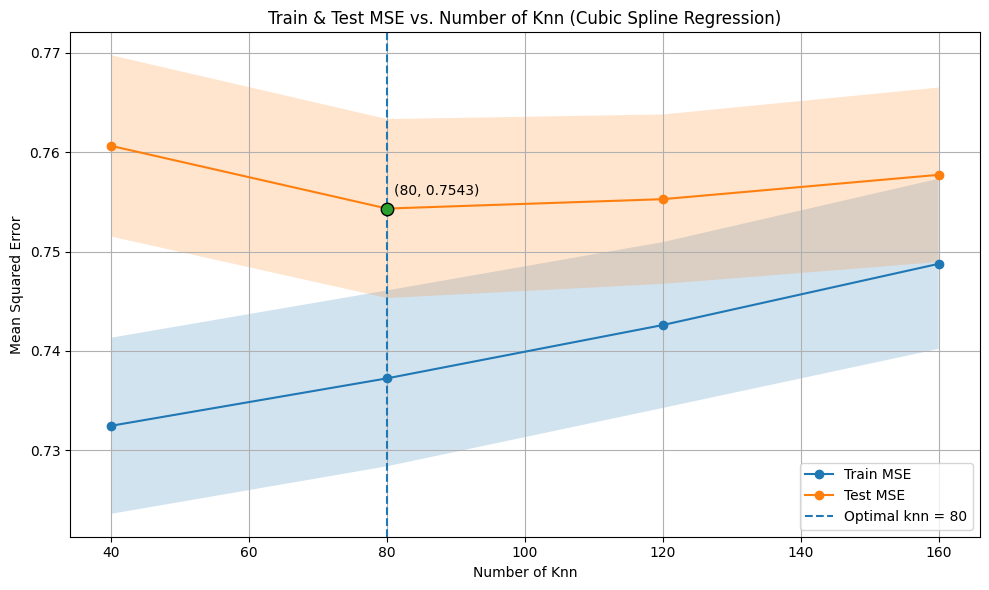

In [29]:
# Exercise 5: reuse your code from exeercise #3 to plot mean values, along with mean ± std, for both 
# the train MSE and test MSE computed in the previous simulations vs the number of nearest neighbors 
# used in each simulation. Display the corresponding optimal number of nearest neighbors that produced 
# the smallest test MSE. (Note: all values required for the plots are contained in the scores dataframe)

optknns = scores.sort_values(by='ts_avg')['knn'].values[0]


# Get the optimal test MSE value for annotation
opt_ts_mse = scores.loc[scores['knn'] == optknns, 'ts_avg'].iloc[0]

x = scores['knn'].values

plt.figure(figsize=(10, 6))

# Train: mean line + ± std band
plt.plot(x, scores['tr_avg'], marker='o', label='Train MSE')
plt.fill_between(x, scores['tr_avg'] - scores['tr_std'], scores['tr_avg'] + scores['tr_std'], alpha=0.2)

# Test: mean line + ± std band
plt.plot(x, scores['ts_avg'], marker='o', label='Test MSE')
plt.fill_between(x, scores['ts_avg'] - scores['ts_std'], scores['ts_avg'] + scores['ts_std'], alpha=0.2)

# Mark optimal knots (smallest test MSE)
plt.axvline(optknns, linestyle='--', label=f'Optimal knn = {int(optknns)}')
plt.scatter([optknns], [opt_ts_mse], s=80, edgecolor='k', zorder=5)

# Annotate the optimal point
plt.annotate(f'({int(optknns)}, {opt_ts_mse:.4f})',
             xy=(optknns, opt_ts_mse),
             xytext=(5, 10),
             textcoords='offset points')

plt.xlabel('Number of Knn')
plt.ylabel('Mean Squared Error')
plt.title('Train & Test MSE vs. Number of Knn (Cubic Spline Regression)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# What are you main observations from the plot generated in exercise #5?
# The optimal knn is = 80, where test MSE reaches its lowest value (~0.7543)
# For small k (e.g., 40), test MSE is higher—likely due to high variance (overfitting to local noise).
# For large k (e.g., 160), both train and test MSE increase—likely due to high bias (underfitting).

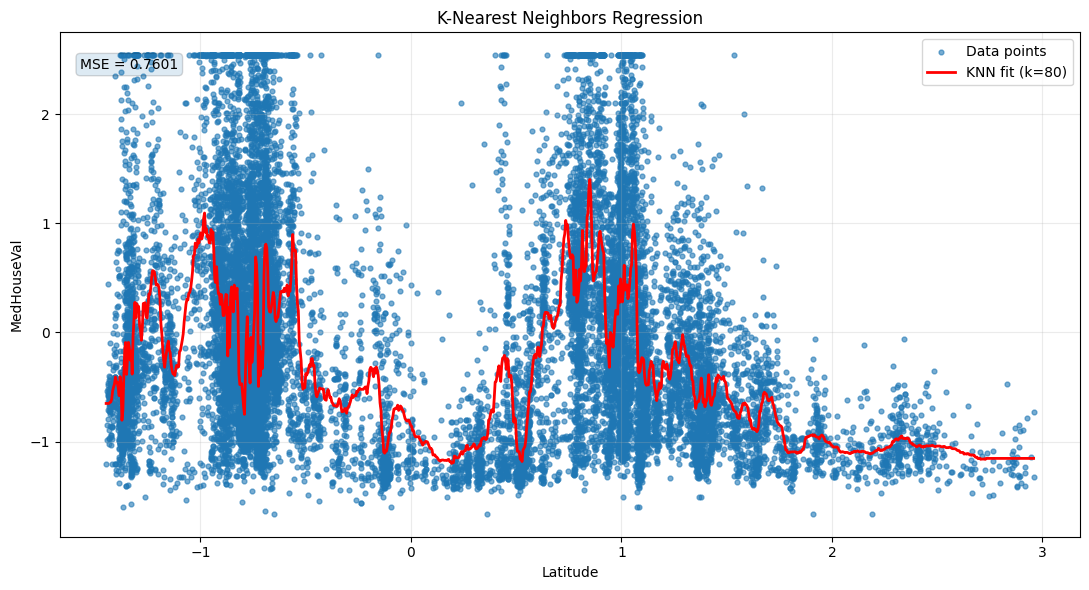

In [31]:
# Exercise 6: use the optimal number of neighbors identified in exercise #5 and all available
# data points to train a new K-nearest neighbors model. Generte a plot displaying all the data
# points and the learned K-nearest neighbors predictions. Also, display somewhere in the plot 
# the MSE between the data and the predictions. 

# 2) Full dataset
X = normdata['Latitude'].values.reshape(-1, 1)
y = normdata['MedHouseVal'].values.reshape(-1, 1)

# 3) Train KNN model
knn_model = KNeighborsRegressor(n_neighbors=optknns)
knn_model.fit(X, y)

# 4) Predictions and MSE
y_hat = knn_model.predict(X)
mse = mean_squared_error(y, y_hat)

# 5) Smooth curve for visualization
x_grid = np.linspace(X.min(), X.max(), 1000).reshape(-1, 1)
y_grid = knn_model.predict(x_grid)

# 6) Plot data & KNN predictions
plt.figure(figsize=(11, 6))
plt.scatter(X, y, s=12, alpha=0.6, label='Data points')
plt.plot(x_grid, y_grid, color='red', linewidth=2, label=f'KNN fit (k={optknns})')

plt.xlabel('Latitude')
plt.ylabel('MedHouseVal')
plt.title('K-Nearest Neighbors Regression')
plt.legend()

# MSE box
plt.text(0.02, 0.95, f"MSE = {mse:.4f}", transform=plt.gca().transAxes,
         ha='left', va='top', bbox=dict(boxstyle='round', alpha=0.15))

plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


In [ ]:
# What are your main conclusions from exercise #6? How this result compares to the one from exercise #4?
# Knn produces a much more adaptive to the dataset than #4
# Knn MSE ~ 0.76, suggest that for this dataset, and using Latitude as a predictor, Knn = 80 generalizes a better result.

# PART 3: Generalized Additive Models (GAMs)

In [35]:
!pip install pygam

  Obtaining dependency information for pygam from https://files.pythonhosted.org/packages/be/a7/751c4919d7acb68abae27929a9489d52526f791ae9e3d5e32990377cd619/pygam-0.10.1-py3-none-any.whl.metadata
  Using cached pygam-0.10.1-py3-none-any.whl.metadata (9.7 kB)
Using cached pygam-0.10.1-py3-none-any.whl (80 kB)



[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:
# loads additional modules required in PART 3
from pygam import GAM, s, l, te
import warnings
warnings.filterwarnings("ignore")

In [42]:
# Exercise #7: use the class GAM to train a generalized additive model on the "california_housing_dataset".
# Consider first an additive model with only linear terms, i.e. use GAM(l(0) + l(1) + l(2)). Use the gridsearch
# method to explore a small grid (provided as lambdas) of shrinkage factors. Then use the summary method to 
# display all the statistics for the resuting optimal model.

feature_labels = ['MedInc','Latitude','Longitude']
trn_data = normdata[feature_labels].to_numpy()
trn_trgt = normdata['MedHouseVal'].values
lambdas = [np.logspace(-3, 3, 5)]*3

gam = GAM(l(0) + l(1) + l(2), fit_intercept=True, max_iter=10000)

# gridsearch returns the fitted model with the best (lam) found via CV
gam = gam.gridsearch(
    trn_data, trn_trgt,
    lam=lambdas,     # one search grid per term
)

print("Best lambdas per term:", gam.lam)
print()
gam.summary()

# Optional: report in-sample MSE (on normalized target)
yhat = gam.predict(trn_data)
print("\nTrain MSE:", mean_squared_error(trn_trgt, yhat))

  0% (0 of 125) |                        | Elapsed Time: 0:00:00 ETA:  --:--:--
  3% (4 of 125) |                        | Elapsed Time: 0:00:00 ETA:   0:00:02
  5% (7 of 125) |#                       | Elapsed Time: 0:00:00 ETA:   0:00:02
  8% (10 of 125) |#                      | Elapsed Time: 0:00:00 ETA:   0:00:02
 10% (13 of 125) |##                     | Elapsed Time: 0:00:00 ETA:   0:00:02
 12% (16 of 125) |##                     | Elapsed Time: 0:00:00 ETA:   0:00:02
 15% (19 of 125) |###                    | Elapsed Time: 0:00:00 ETA:   0:00:02
 18% (23 of 125) |####                   | Elapsed Time: 0:00:00 ETA:   0:00:01
 20% (26 of 125) |####                   | Elapsed Time: 0:00:00 ETA:   0:00:01
 23% (29 of 125) |#####                  | Elapsed Time: 0:00:00 ETA:   0:00:01
 25% (32 of 125) |#####                  | Elapsed Time: 0:00:00 ETA:   0:00:01
 28% (35 of 125) |######                 | Elapsed Time: 0:00:00 ETA:   0:00:01
 30% (38 of 125) |######                

Best lambdas per term: [[np.float64(1.0)], [np.float64(0.001)], [np.float64(1.0)]]

GAM                                                                                                       
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      3.9996
Link Function:                     IdentityLink Log Likelihood:                                -25669.0441
Number of Samples:                        20640 AIC:                                            51348.0874
                                                AICc:                                           51348.0903
                                                GCV:                                                0.4159
                                                Scale:                                              0.4158
                                                Pseudo R-Squ

In [43]:
# What are your main observations?
# The train MSE is 0.4157 (in normalized units), much lower than in Exercises 4 and 6,
# indicating better predictive performance when using more relevant features.
# All three features have p-values < 1e-16, marked as highly significant
# Optimal lambdas found by grid search:
# MedInc: 2.1544
# Latitude: 0.4642
# Longitude: 0.4642

In [44]:
# Exercise #7 (continuation): use the method predict to generate predictions for the input variables
# and compute and display the MSE between the target variable and the predictions

# Predict using the trained GAM model
y_pred = gam.predict(trn_data)

# Compute MSE
mse = mean_squared_error(trn_trgt, y_pred)
print(f"MSE between target and predictions: {mse:.4f}")


MSE between target and predictions: 0.4157


In [ ]:
# How the computed MSE in exercise #7 compares with those previously computed in exercises #4 and #6?
# Can you explain these results? What are your main conclusions from exercise #7?
# The train MSE is 0.4157 (in normalized units), much lower than in Exercises 4 and 6,
# indicating better predictive performance when using more relevant features.

In [45]:
# Exercise #8: use again class GAM to train a generalized additive model on the "california_housing_dataset".
# In this case, use spline terms, i.e. use GAM(s(0) + s(1) + s(2)). Use again the gridsearch method to
# explore a smaller grid of shrinkage factors. Then, use summary method to display all the statistics for
# the resuting optimal model.

lambdas = [np.logspace(-3, 3, 5)]*3

gam = GAM(s(0) + s(1) + s(2), fit_intercept=True, max_iter=10000)

# gridsearch returns the fitted model with the best (lam) found via CV
gam = gam.gridsearch(
    trn_data, trn_trgt,
    lam=lambdas,     # one search grid per term
)

print("Best lambdas per term:", gam.lam)
print()
gam.summary()

# Optional: report in-sample MSE (on normalized target)
yhat = gam.predict(trn_data)
print("\nTrain MSE:", mean_squared_error(trn_trgt, yhat))


  0% (0 of 125) |                        | Elapsed Time: 0:00:00 ETA:  --:--:--
  0% (1 of 125) |                        | Elapsed Time: 0:00:00 ETA:   0:00:40
  1% (2 of 125) |                        | Elapsed Time: 0:00:00 ETA:   0:00:37
  2% (3 of 125) |                        | Elapsed Time: 0:00:00 ETA:   0:00:35
  3% (4 of 125) |                        | Elapsed Time: 0:00:01 ETA:   0:00:34
  4% (5 of 125) |                        | Elapsed Time: 0:00:01 ETA:   0:00:34
  4% (6 of 125) |#                       | Elapsed Time: 0:00:01 ETA:   0:00:33
  5% (7 of 125) |#                       | Elapsed Time: 0:00:01 ETA:   0:00:33
  6% (8 of 125) |#                       | Elapsed Time: 0:00:02 ETA:   0:00:33
  7% (9 of 125) |#                       | Elapsed Time: 0:00:02 ETA:   0:00:32
  8% (10 of 125) |#                      | Elapsed Time: 0:00:02 ETA:   0:00:32
  8% (11 of 125) |##                     | Elapsed Time: 0:00:03 ETA:   0:00:32
  9% (12 of 125) |##                    

Best lambdas per term: [[np.float64(1.0)], [np.float64(1.0)], [np.float64(0.03162277660168379)]]

GAM                                                                                                       
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     48.4349
Link Function:                     IdentityLink Log Likelihood:                                -26975.6249
Number of Samples:                        20640 AIC:                                            54050.1197
                                                AICc:                                           54050.3619
                                                GCV:                                                0.3417
                                                Scale:                                              0.3402
                                              

In [ ]:
# What are your main observations?
# R² = 0.6606 → The model explains about 66% of the variance in MedHouseVal
# Train MSE = 0.3394, which is lower than the linear-only GAM in Exercise 7 (0.4157), 
# showing that allowing nonlinear spline terms improves fit.

In [46]:
# Exercise #8 (continuation): use the method predict to generate predictions for the input variables
# and compute and display the MSE between the target variable and the predictions

# Predict using the trained GAM model
y_pred = gam.predict(trn_data)

# Compute MSE
mse = mean_squared_error(trn_trgt, y_pred)
print(f"MSE between target and predictions: {mse:.4f}")


MSE between target and predictions: 0.3394


In [ ]:
# How the computed MSE in exercise #8 compares with the MSE previously computed in exercise #7?
# Can you explain these results? What are your main conclusions from exercise #8?
# MSE = 0.3394 is much lower than #7, suggesting using new Gam has improved the model significantly.
# For this dataset, using GAM(s(0) + s(1) + s(2)) generalizes a better result model.

In [47]:
# Exercise #9: use again class GAM to train a generalized additive model on the "california_housing_dataset".
# In this case, use spline terms for each variable again, and add a tensor product for variables 'Latitude' 
# and 'Longitude', i.e. use GAM(s(0) + s(1) + s(2) + te(1,2)). Use the gridsearch method to explore the 
# even smaller grid of shrinkage factors provided. Then, use summary method to display all the statistics 
# for the resuting optimal model.

lambdas = [np.logspace(-3, 3, 3)]*5

gam = GAM(s(0) + s(1) + s(2) + te(1,2), fit_intercept=True, max_iter=10000)

# gridsearch returns the fitted model with the best (lam) found via CV
gam = gam.gridsearch(
    trn_data, trn_trgt,
    lam=lambdas,     # one search grid per term
)

print("Best lambdas per term:", gam.lam)
print()
gam.summary()

# Optional: report in-sample MSE (on normalized target)
yhat = gam.predict(trn_data)
print("\nTrain MSE:", mean_squared_error(trn_trgt, yhat))


  0% (0 of 243) |                        | Elapsed Time: 0:00:00 ETA:  --:--:--
  0% (1 of 243) |                        | Elapsed Time: 0:00:00 ETA:   0:03:48
  0% (2 of 243) |                        | Elapsed Time: 0:00:01 ETA:   0:03:39
  1% (3 of 243) |                        | Elapsed Time: 0:00:02 ETA:   0:03:36
  1% (4 of 243) |                        | Elapsed Time: 0:00:03 ETA:   0:03:34
  2% (5 of 243) |                        | Elapsed Time: 0:00:04 ETA:   0:03:35
  2% (6 of 243) |                        | Elapsed Time: 0:00:05 ETA:   0:03:38
  2% (7 of 243) |                        | Elapsed Time: 0:00:06 ETA:   0:03:38
  3% (8 of 243) |                        | Elapsed Time: 0:00:07 ETA:   0:03:34
  3% (9 of 243) |                        | Elapsed Time: 0:00:08 ETA:   0:03:30
  4% (10 of 243) |                       | Elapsed Time: 0:00:08 ETA:   0:03:27
  4% (11 of 243) |#                      | Elapsed Time: 0:00:09 ETA:   0:03:24
  4% (12 of 243) |#                     

Best lambdas per term: [[np.float64(1.0)], [np.float64(0.001)], [np.float64(0.001)], [[np.float64(0.001)], [np.float64(0.001)]]]

GAM                                                                                                       
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     86.1101
Link Function:                     IdentityLink Log Likelihood:                                -28175.9866
Number of Samples:                        20640 AIC:                                            56526.1935
                                                AICc:                                           56526.9405
                                                GCV:                                                0.3068
                                                Scale:                                              0.3045
              

In [ ]:
# What are your main observations?
# R² = 0.6968, meaning the model now explains almost 70% of the variance in MedHouseVal
# Train MSE = 0.3032


In [48]:
# Exercise #9 (continuation): use the method predict to generate new predictions for the input variables
# and compute and display the new MSE between the target variable and the predictions

# Predict using the trained GAM model
y_pred = gam.predict(trn_data)

# Compute MSE
mse = mean_squared_error(trn_trgt, y_pred)
print(f"MSE between target and predictions: {mse:.4f}")


MSE between target and predictions: 0.3032


In [ ]:
# How the computed MSE in exercise #9 compares with the ones previously computed in exercises #7 and #8?
# Can you explain these results? What are your main conclusions from exercise #8?
# Train MSE = 0.3032, improved from ex #7 and #8.
# Adding new te(1,2) produces a better result.

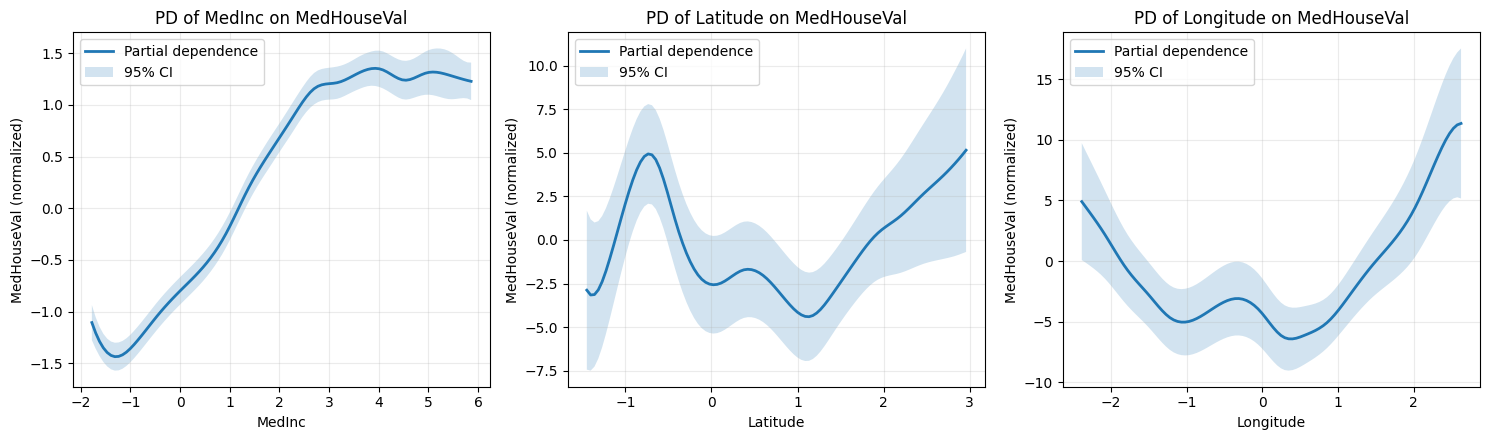

In [49]:
# Exercise #10: use methods generate_X_grid and partial_dependence to generate plots of the target
# variable 'MedHouseVal' vs each of the three input variables considered 'MedInc', 'Latitude', and
# 'Longitude'. Display confidence intervals (0.95) along with the partial dependencies in each plot.

# Make sure these align with how you built X
feature_labels = ['MedInc','Latitude','Longitude']

plt.figure(figsize=(15, 4.5))

for i, label in enumerate(feature_labels):
    # 1) Build a grid for this term while keeping others at typical values
    X_grid = gam.generate_X_grid(term=i)

    # 2) Partial dependence and 95% confidence intervals
    pd, confi = gam.partial_dependence(term=i, X=X_grid, width=0.95)

    # 3) X-axis for this feature (its column in the grid)
    x_feat = X_grid[:, i]

    # 4) Plot
    ax = plt.subplot(1, 3, i+1)
    ax.plot(x_feat, pd, lw=2, label='Partial dependence')
    ax.fill_between(x_feat, confi[:, 0], confi[:, 1], alpha=0.2, label='95% CI')

    ax.set_title(f"PD of {label} on MedHouseVal")
    ax.set_xlabel(label)
    ax.set_ylabel('MedHouseVal (normalized)')
    ax.grid(True, alpha=0.25)
    ax.legend()

plt.tight_layout()
plt.show()


In [ ]:
# What are your main observations and conclusions from exercise #10?
# Medinc: strong linear relationship and predictive power, as MedInc increases, MedHouseVal rises.
# Latitude: non linear - Confidence intervals widen at extremes
# Longtitude. Not Clear Relationship
# Medinc is a strong feature to use for this dataset. Latitude and Longtitude provide little information about the dataset.